In [1]:
%load_ext autoreload
%autoreload 2

import h5py, os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)

from tqdm import tqdm
from trianglechain import TriangleChain

from msfm.utils import files, observation, catalog, buzzard

from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import configuration
from deep_lss.nets.mlp import MultiLayerPerceptron

from msi.utils import preprocessing, dataset

2026-03-02 07:01:13.541905: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-02 07:01:13.541930: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-02 07:01:13.543234: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-02 07:01:13.550681: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 07:01:15.852077: W tensorflow/compiler/tf2

# v16

In [2]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v16/default.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v16/default"

out_dir = "/pscratch/sd/a/athomsen/deep_lss/v16/default/cls"
file_label = None

In [3]:
# lensing
dlss_conf = configuration.load_deep_lss_config(
    f"/global/u2/a/athomsen/y3-deep-lss/configs/v16/default/lensing/dlss.yaml"
)

26-03-02 07:01:25 configuratio INF   Loaded the config 


In [4]:
# # clustering
# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v16/default/clustering/dlss.yaml"
# )

In [5]:
# # combined
# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v16/default/combined/dlss.yaml"
# )

# training

In [6]:
params = dlss_conf["dset"]["training"]["params"]
with_lensing = dlss_conf["dset"]["common"]["with_lensing"]
with_clustering = dlss_conf["dset"]["common"]["with_clustering"]
with_cross_z = True

apply_log = True
standardize = False
batch_size = 2**10
# n_steps = 100_000
n_steps = 500_000

rng = np.random.default_rng(12)

if with_lensing and not with_clustering:
    out_dir = os.path.join(out_dir, "lensing")
elif with_clustering and not with_lensing:
    out_dir = os.path.join(out_dir, "clustering")
elif with_lensing and with_clustering:
    out_dir = os.path.join(out_dir, "combined")

if file_label is not None:
    out_dir = os.path.join(out_dir, file_label)
os.makedirs(out_dir, exist_ok=True)    

pred_file = os.path.join(out_dir, f"preds_{n_steps}.h5")

print("base_dir = ", base_dir)
print("pred_file = ", pred_file)

base_dir =  /pscratch/sd/a/athomsen/v11desy3/v16/default
pred_file =  /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/preds_500000.h5


## data

26-03-02 07:01:26 configuratio INF   Loaded the config 
26-03-02 07:01:26 preprocessin INF   Using theta_fwhm = [29.5, 20.1, 15.0, 12.6, 130.2, 88.9, 68.1, 57.0] from the dlss config 
26-03-02 07:01:26 preprocessin INF   Using white_noise_sigma = [0.00030275, 0.00040448, 0.00048782, 0.00052049, 0.85135, 0.34375, 0.25989, 0.24127] from the dlss config 
26-03-02 07:01:26 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  82.94930876
 121.4848144  158.59030837 189.47368421] from the dlss config 
26-03-02 07:01:26 preprocessin INF   Using l_mins = [0. 0. 0. 0. 0. 0. 0. 0.] by default (no smoothing) 
26-03-02 07:01:26 preprocessin INF   Using n_bins = 33 from the msfm config 
26-03-02 07:01:26 preprocessin INF   Loading the pre-binned Cls 
26-03-02 07:01:26 input_output INF   Loading summaries from /pscratch/sd/a/athomsen/v11desy3/v16/default 
26-03-02 07:01:26 input_output INF   Array shapes: 
26-03-02 07:01:26 input_output INF   fiducial/i_example = (4

2026-03-02 07:01:52.479139: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 33939 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0


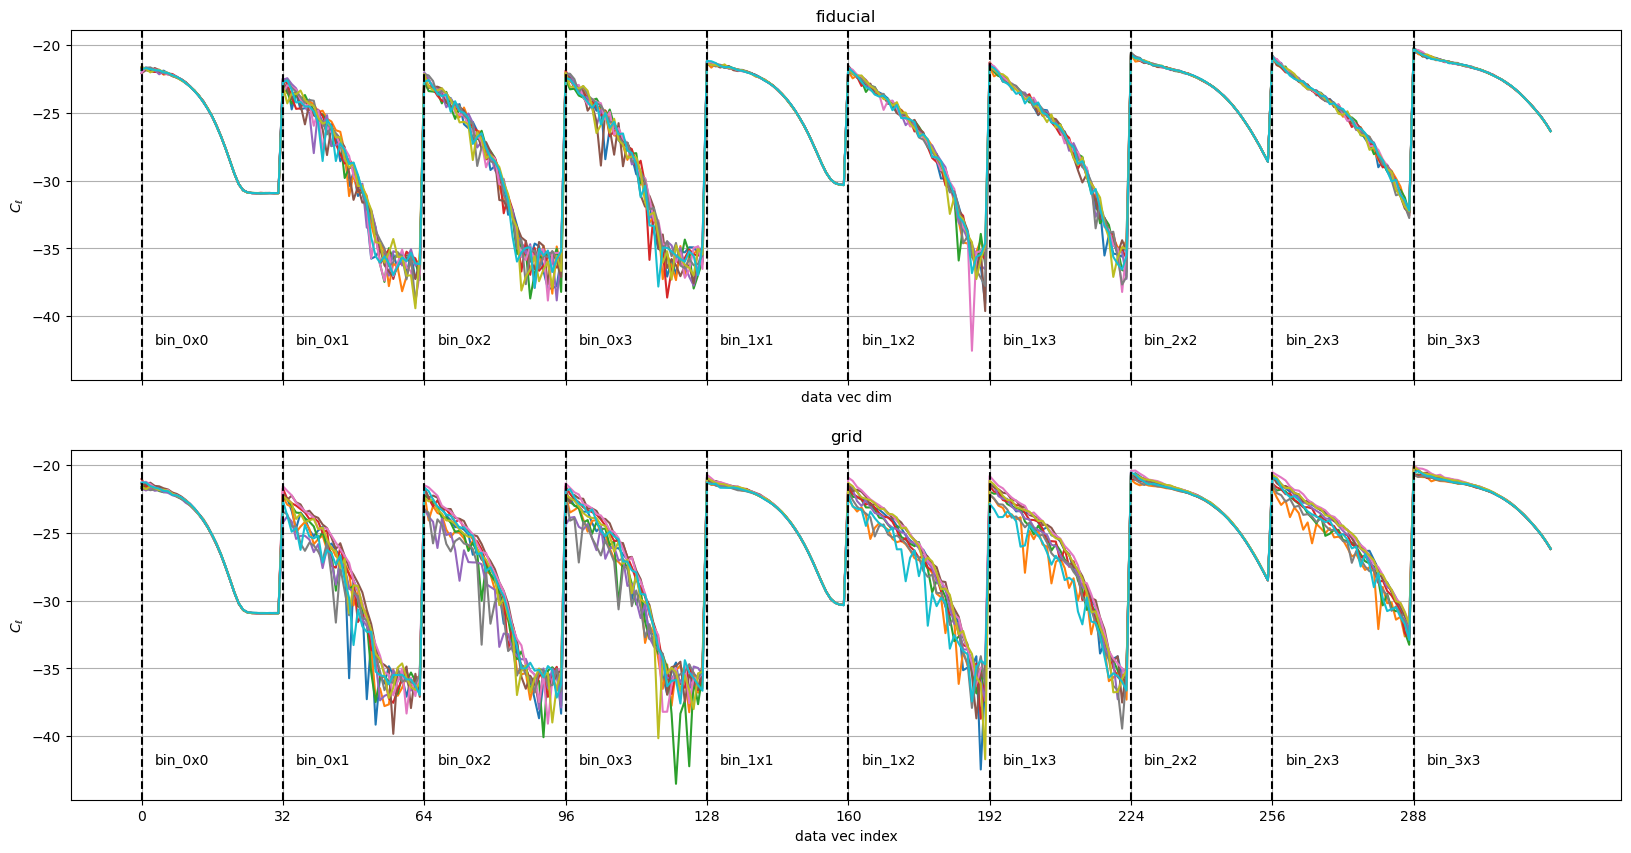

In [7]:
cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    # dset
    batch_size=batch_size,
    # preprocessing
    apply_log=apply_log,
    standardize=standardize,
)

## network

In [8]:
n_cls = out_dict["grid/cls/train"].shape[-1]
n_params = len(params)
n_summary = 2 * n_params

num_hidden_units = 1024
num_layers = 2

dropout_rate = 0.1

def get_cl_summary_network(n_summary=n_summary):
    mlp = MultiLayerPerceptron(
        output_size=n_summary, 
        num_hidden_units=num_hidden_units, 
        num_layers=num_layers, 
        dropout_rate=dropout_rate
    )
    mlp.build((None, n_cls))
    mlp.summary()
    
    return mlp

In [9]:
def train_model(model, eval_every=None):
    do_validation = eval_every is not None
    
    train_losses = []
    train_steps = []
    vali_steps = []
    vali_losses = []
    for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(n_steps+1)), total=n_steps):
        train_losses.append(model.grid_train_step(cl_batch, cosmo_batch))
        train_steps.append(i)
        
        if do_validation and (i % eval_every == 0) and (i !=0):
            vali_loss = []
            for cl_batch, cosmo_batch in cl_dset_test:
                vali_loss.append(model.vali_loss_fn(model(cl_batch, training=False), cosmo_batch))
            vali_losses.append(np.mean(vali_loss))
            vali_steps.append(i)

    fig, ax = plt.subplots()
    ax.plot(train_steps[100:], train_losses[100:], label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend()
    
    if do_validation:
        print(f"final validation loss = {vali_losses[-1]}")
        
    model.save_model()

## VMIM

In [10]:
learning_rate = 1e-4
optimizer = tf.keras.optimizers.Adam(learning_rate)

summary_net = get_cl_summary_network()
    
model = GridLossModel(
    summary_net,
    n_side=None,
    indices=None,
    optimizer=optimizer,
    checkpoint_dir=os.path.join(out_dir, "model"),
    summary_dir=os.path.join(out_dir, "history"),
    restore_checkpoint=True,
    # z_bank_size=4*batch_size,
)

# model.restore_model_from_checkpoint_path(
#     os.path.join(out_dir, "model", f"ckpt-{checkpoint_number}")
# )

model.setup_grid_loss_step(
    batch_size=batch_size,
    dim_theta=n_params,
    loss="mutual_info",
    dim_x=n_cls,
    dim_summary=n_summary,
    mutual_info_estimator="variational",
    clip_by_global_norm=1.0,
    mutual_info_kwargs={"full_covariance": False},
    # feature regularization
    # z_type="sw",
    # z_weight=10,
    # z_layer="last",
)

Model: "multi_layer_perceptron"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer_normalization (Layer  multiple                  640       
 Normalization)                                                  
                                                                 
 dense (Dense)               multiple                  328704    
                                                                 
 dropout (Dropout)           multiple                  0         
                                                                 
 dense_1 (Dense)             multiple                  1049600   
                                                                 
 dropout_1 (Dropout)         multiple                  0         
                                                                 
 output (Dense)              multiple                  12300     
                                            

In [11]:
# train_model(model, eval_every=n_steps//10)

# evaluation

In [12]:
def append_obs_to_file(label, pred):
    pred = np.squeeze(pred)
    
    with h5py.File(pred_file, "a") as f:
        if label in f:
            del f[label]
        f.create_dataset(name=label, data=pred)
        print(f"wrote {label}")


## CosmoGrid

### grid

In [13]:
grid_preds = model(out_dict["grid/cls/test"], training=False)
# fidu_preds = model(out_dict["fidu/cls"], training=False)

with h5py.File(pred_file, "w") as f:
    f.create_dataset(name="grid/preds/test", data=grid_preds)
    f.create_dataset(name="grid/cosmos/test", data=out_dict["grid/cosmos/test"])
    # f.create_dataset(name="fidu/preds", data=fidu_preds)
print(f"Wrote to {pred_file}\n")


def plot_summary_space_prior_predictive(obs_pred, n_rand=1_000):
    i_rand = rng.integers(0, grid_preds.shape[0], n_rand)

    tri = TriangleChain(size=2)
    tri.scatter(
        np.array(grid_preds)[i_rand], 
        scatter_kwargs={"s": 10, "marker": "o"}
    )
    tri.scatter(
        obs_pred, 
        scatter_kwargs={"s": 200, "marker": "*"},
        color="k",
        scatter_vline_1D=True,
        plot_histograms_1D=False,
    )


def plot_cls_space_prior_predictive(obs_cl, n_rand=100):
    i_rand = rng.integers(0, grid_preds.shape[0], n_rand)
    
    fig, ax = plt.subplots()
    ax.plot(out_dict["grid/cls/test"][i_rand,:].T, alpha=0.5)
    ax.plot(np.squeeze(obs_cl), alpha=1, color="k", linestyle=":")
    ax.legend(loc="best")
    ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$")


Wrote to /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/preds_500000.h5



2026-03-02 07:01:57.497948: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8903


### benchmarks

In [14]:
obs_labels = []
obs_files = []

obs_dir = os.path.join(base_dir, "obs")

# benchmark
obs_labels.append("bench_fidu")
obs_files.append(os.path.join(obs_dir, "fiducial_bench_obs_maps.h5"))

# obs_labels.append("bench_box")
# obs_files.append(os.path.join(obs_dir, "box_size_obs_maps.h5"))

# obs_labels.append("bench_particle")
# obs_files.append(os.path.join(base_dir, "particle_count_obs_maps.h5"))

# obs_labels.append("bench_redshift")
# obs_files.append(os.path.join(base_dir, "redshift_resolution_obs_maps.h5"))


CosmoGrid mock: bench_fidu
obs_cls_raw.shape = (80, 1536, 36)
26-03-02 07:01:58 configuratio INF   Loaded the config 
26-03-02 07:01:58 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  82.94930876
 121.4848144  158.59030837 189.47368421] from the dlss config 
26-03-02 07:01:58 preprocessin INF   Using l_mins = [0 0 0 0 0 0 0 0] by default (no smoothing) 
26-03-02 07:01:58 preprocessin INF   Adding white noise to the observation 
26-03-02 07:01:58 preprocessin INF   Using the bin indices [ 0  1  2  3  8  9 10 15 16 21] 
26-03-02 07:01:58 preprocessin INF   Taking the logarithm of the absolute values. 


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/66 [00:00<?, ?it/s]

wrote obs/preds/bench_fidu_stack
wrote obs/preds/bench_fidu_mean


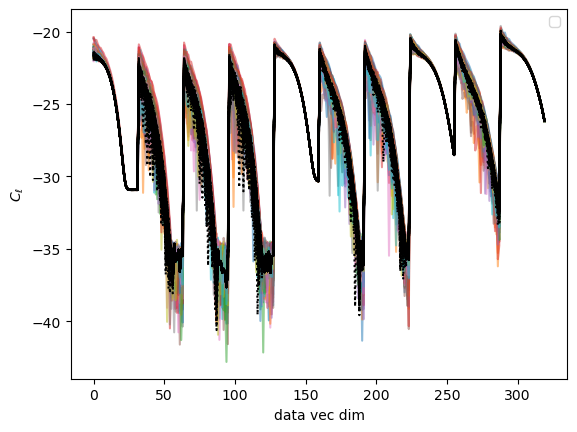

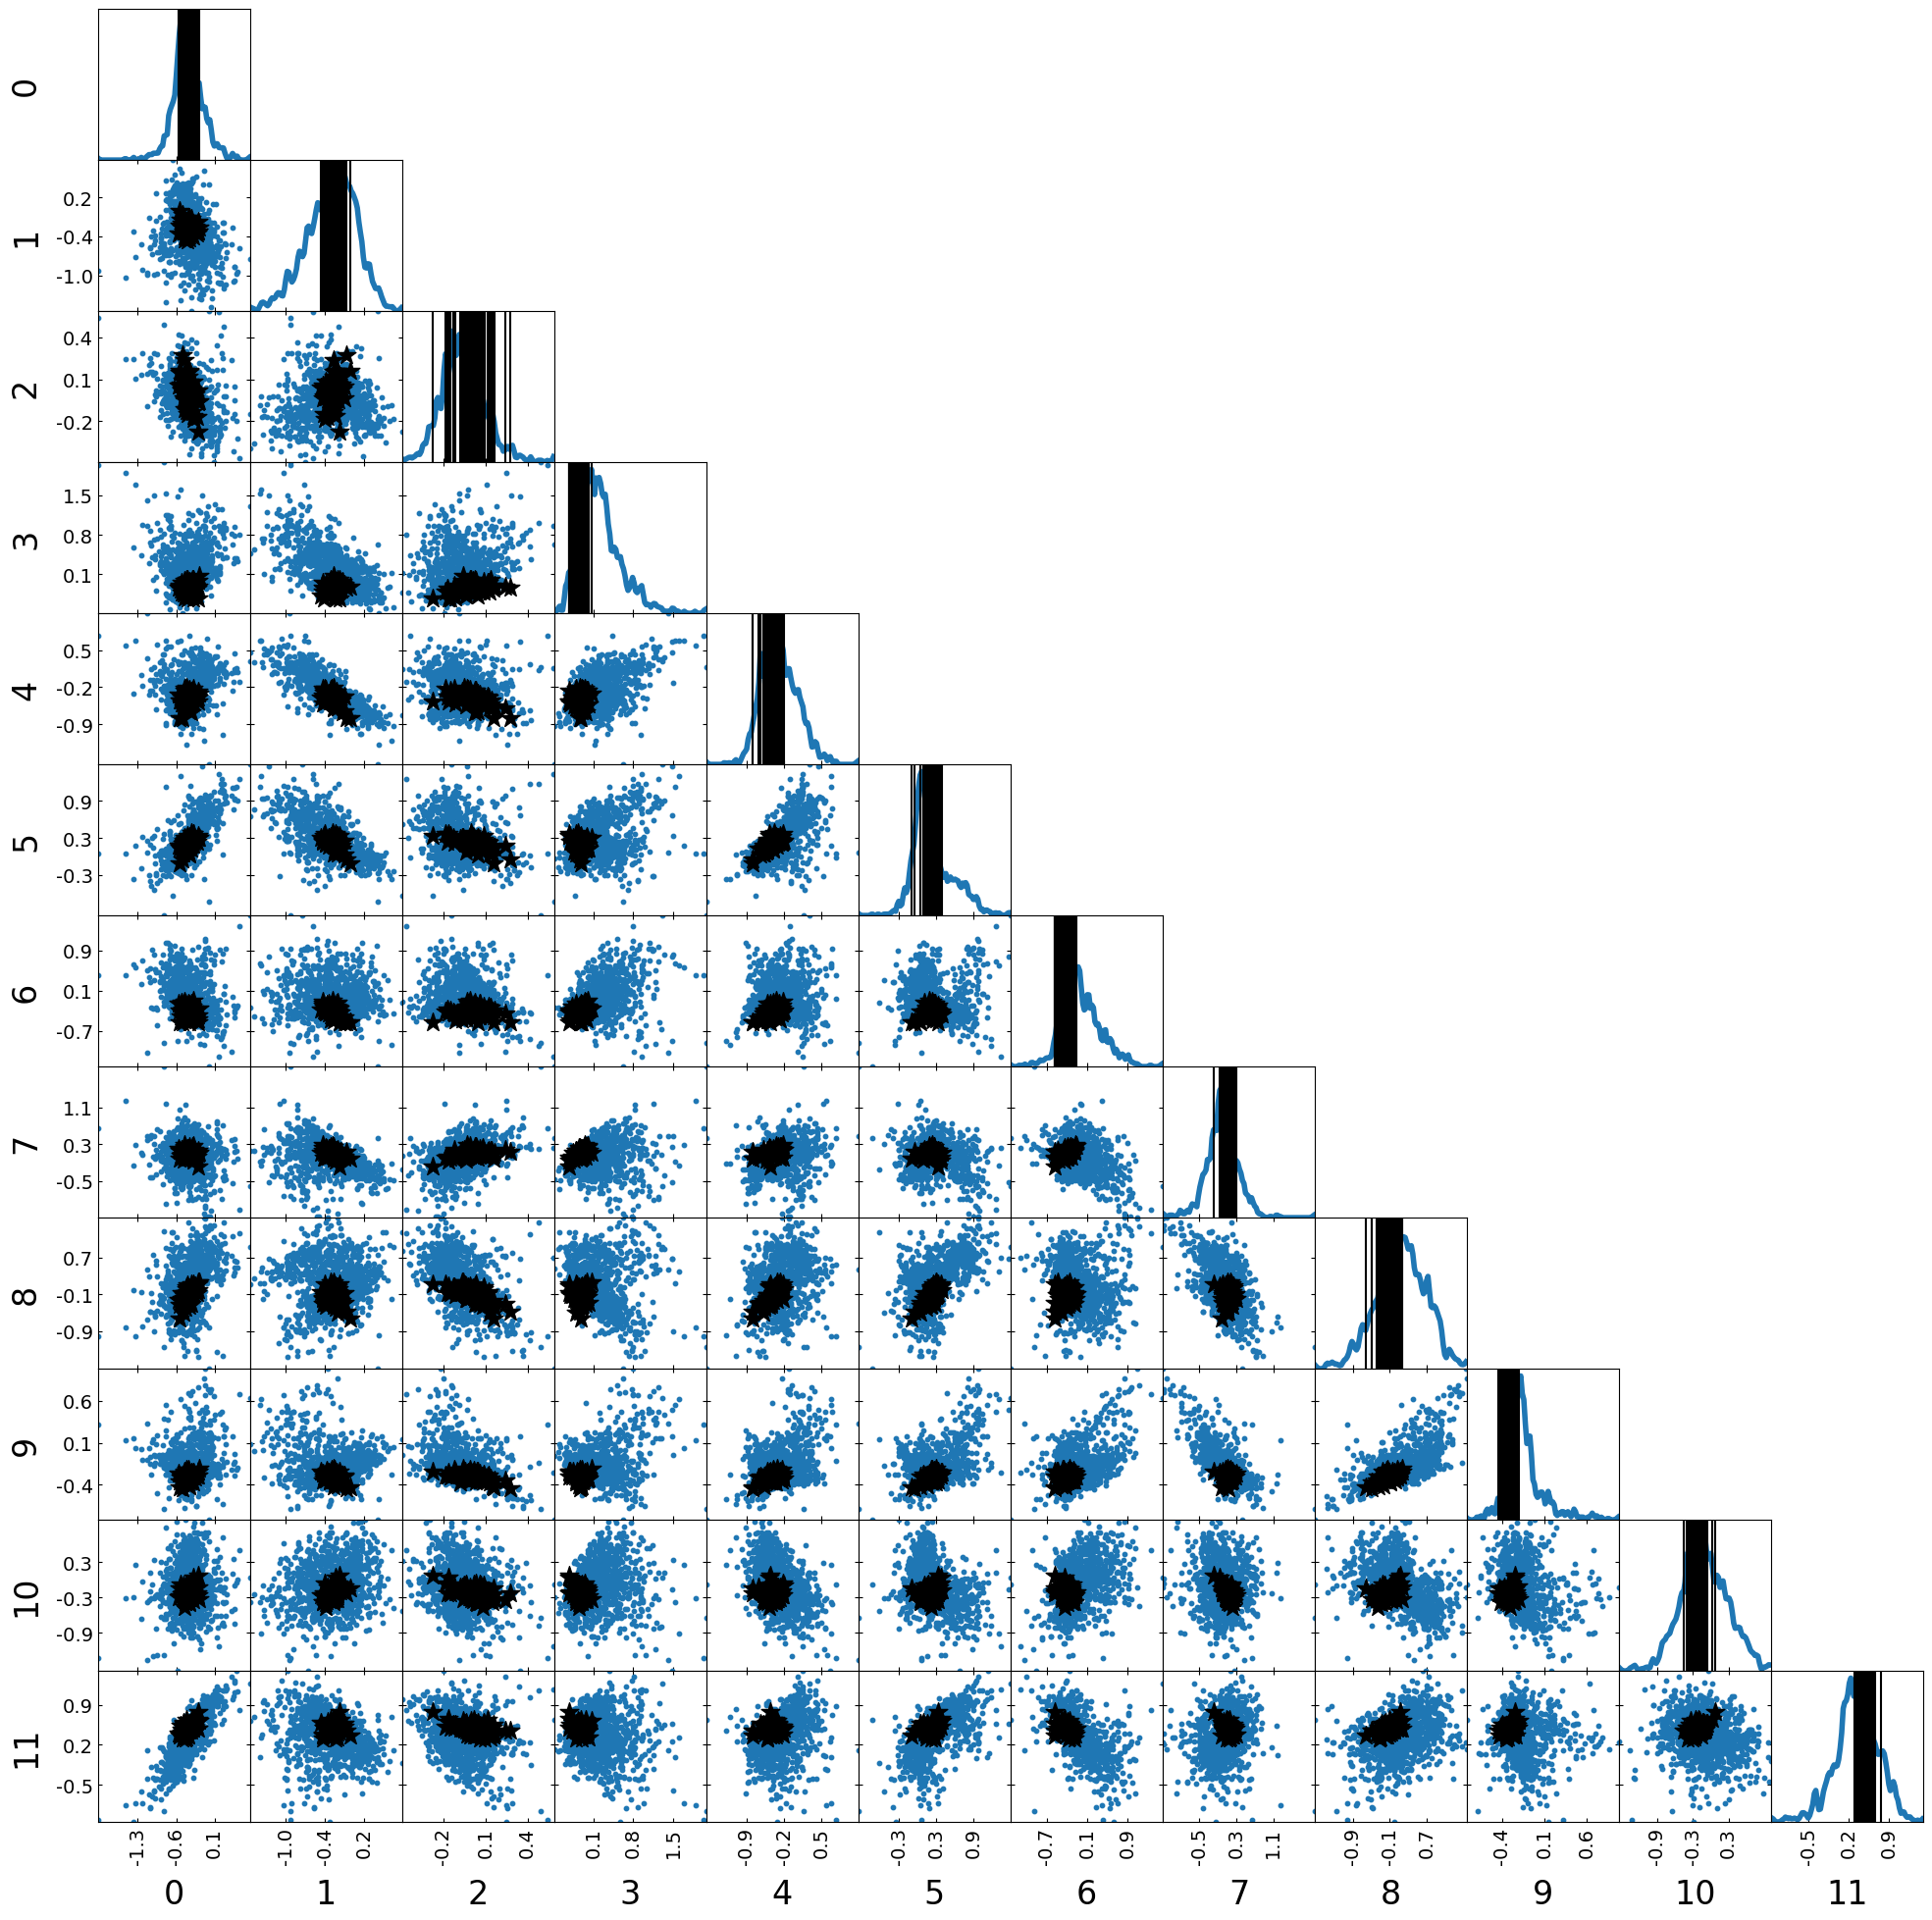

In [15]:
plot_diagnostics = True

for obs_label, obs_file in zip(obs_labels, obs_files):
    print(f"CosmoGrid mock: {obs_label}")
    
    with h5py.File(obs_file, "r") as f_in:
        obs_cls_raw = f_in["obs/cls_raw"][:]
        print("obs_cls_raw.shape =", obs_cls_raw.shape)
    
    # forward model
    obs_cl = preprocessing.get_preprocessed_cl_observation(
        obs_cl=obs_cls_raw,
        # configuration
        msfm_conf=msfm_conf,
        dlss_conf=dlss_conf,
        base_dir=base_dir,
        nest_in=False,
        # selection
        with_lensing=with_lensing,
        with_clustering=with_clustering,
        with_cross_z=with_cross_z,
        with_cross_probe=(with_lensing and with_clustering),
        # additional preprocessing
        apply_log=apply_log,
        standardize=standardize,
        make_plot=False,
    )
    obs_cl = np.squeeze(obs_cl)

    # evaluate
    obs_pred = model(obs_cl, training=False).numpy()

    if plot_diagnostics:
        plot_cls_space_prior_predictive(obs_cl.T)
        plot_summary_space_prior_predictive(obs_pred)

    # save
    obs_label = f"obs/preds/{obs_label}"
    append_obs_to_file(obs_label + "_stack", obs_pred)
    append_obs_to_file(obs_label + "_mean", np.mean(obs_pred, axis=0))


## DES Y3 

26-03-02 07:02:07   catalog.py INF   Loaded metacal maps from cache 
26-03-02 07:02:07   catalog.py INF   Loaded maglim map from cache 
26-03-02 07:02:07 configuratio INF   Loaded the config 
26-03-02 07:02:07 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  82.94930876
 121.4848144  158.59030837 189.47368421] from the dlss config 
26-03-02 07:02:07 preprocessin INF   Using l_mins = [0 0 0 0 0 0 0 0] by default (no smoothing) 
26-03-02 07:02:09 observation. INF   Forward modeling the weak lensing map 
26-03-02 07:02:13 observation. INF   Forward modeling the galaxy clustering map 
26-03-02 07:02:15 preprocessin INF   Adding white noise to the observation 
26-03-02 07:02:15 preprocessin INF   Using the bin indices [ 0  1  2  3  8  9 10 15 16 21] 
26-03-02 07:02:15 preprocessin INF   Taking the logarithm of the absolute values. 


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/66 [00:00<?, ?it/s]

wrote obs/preds/DESy3


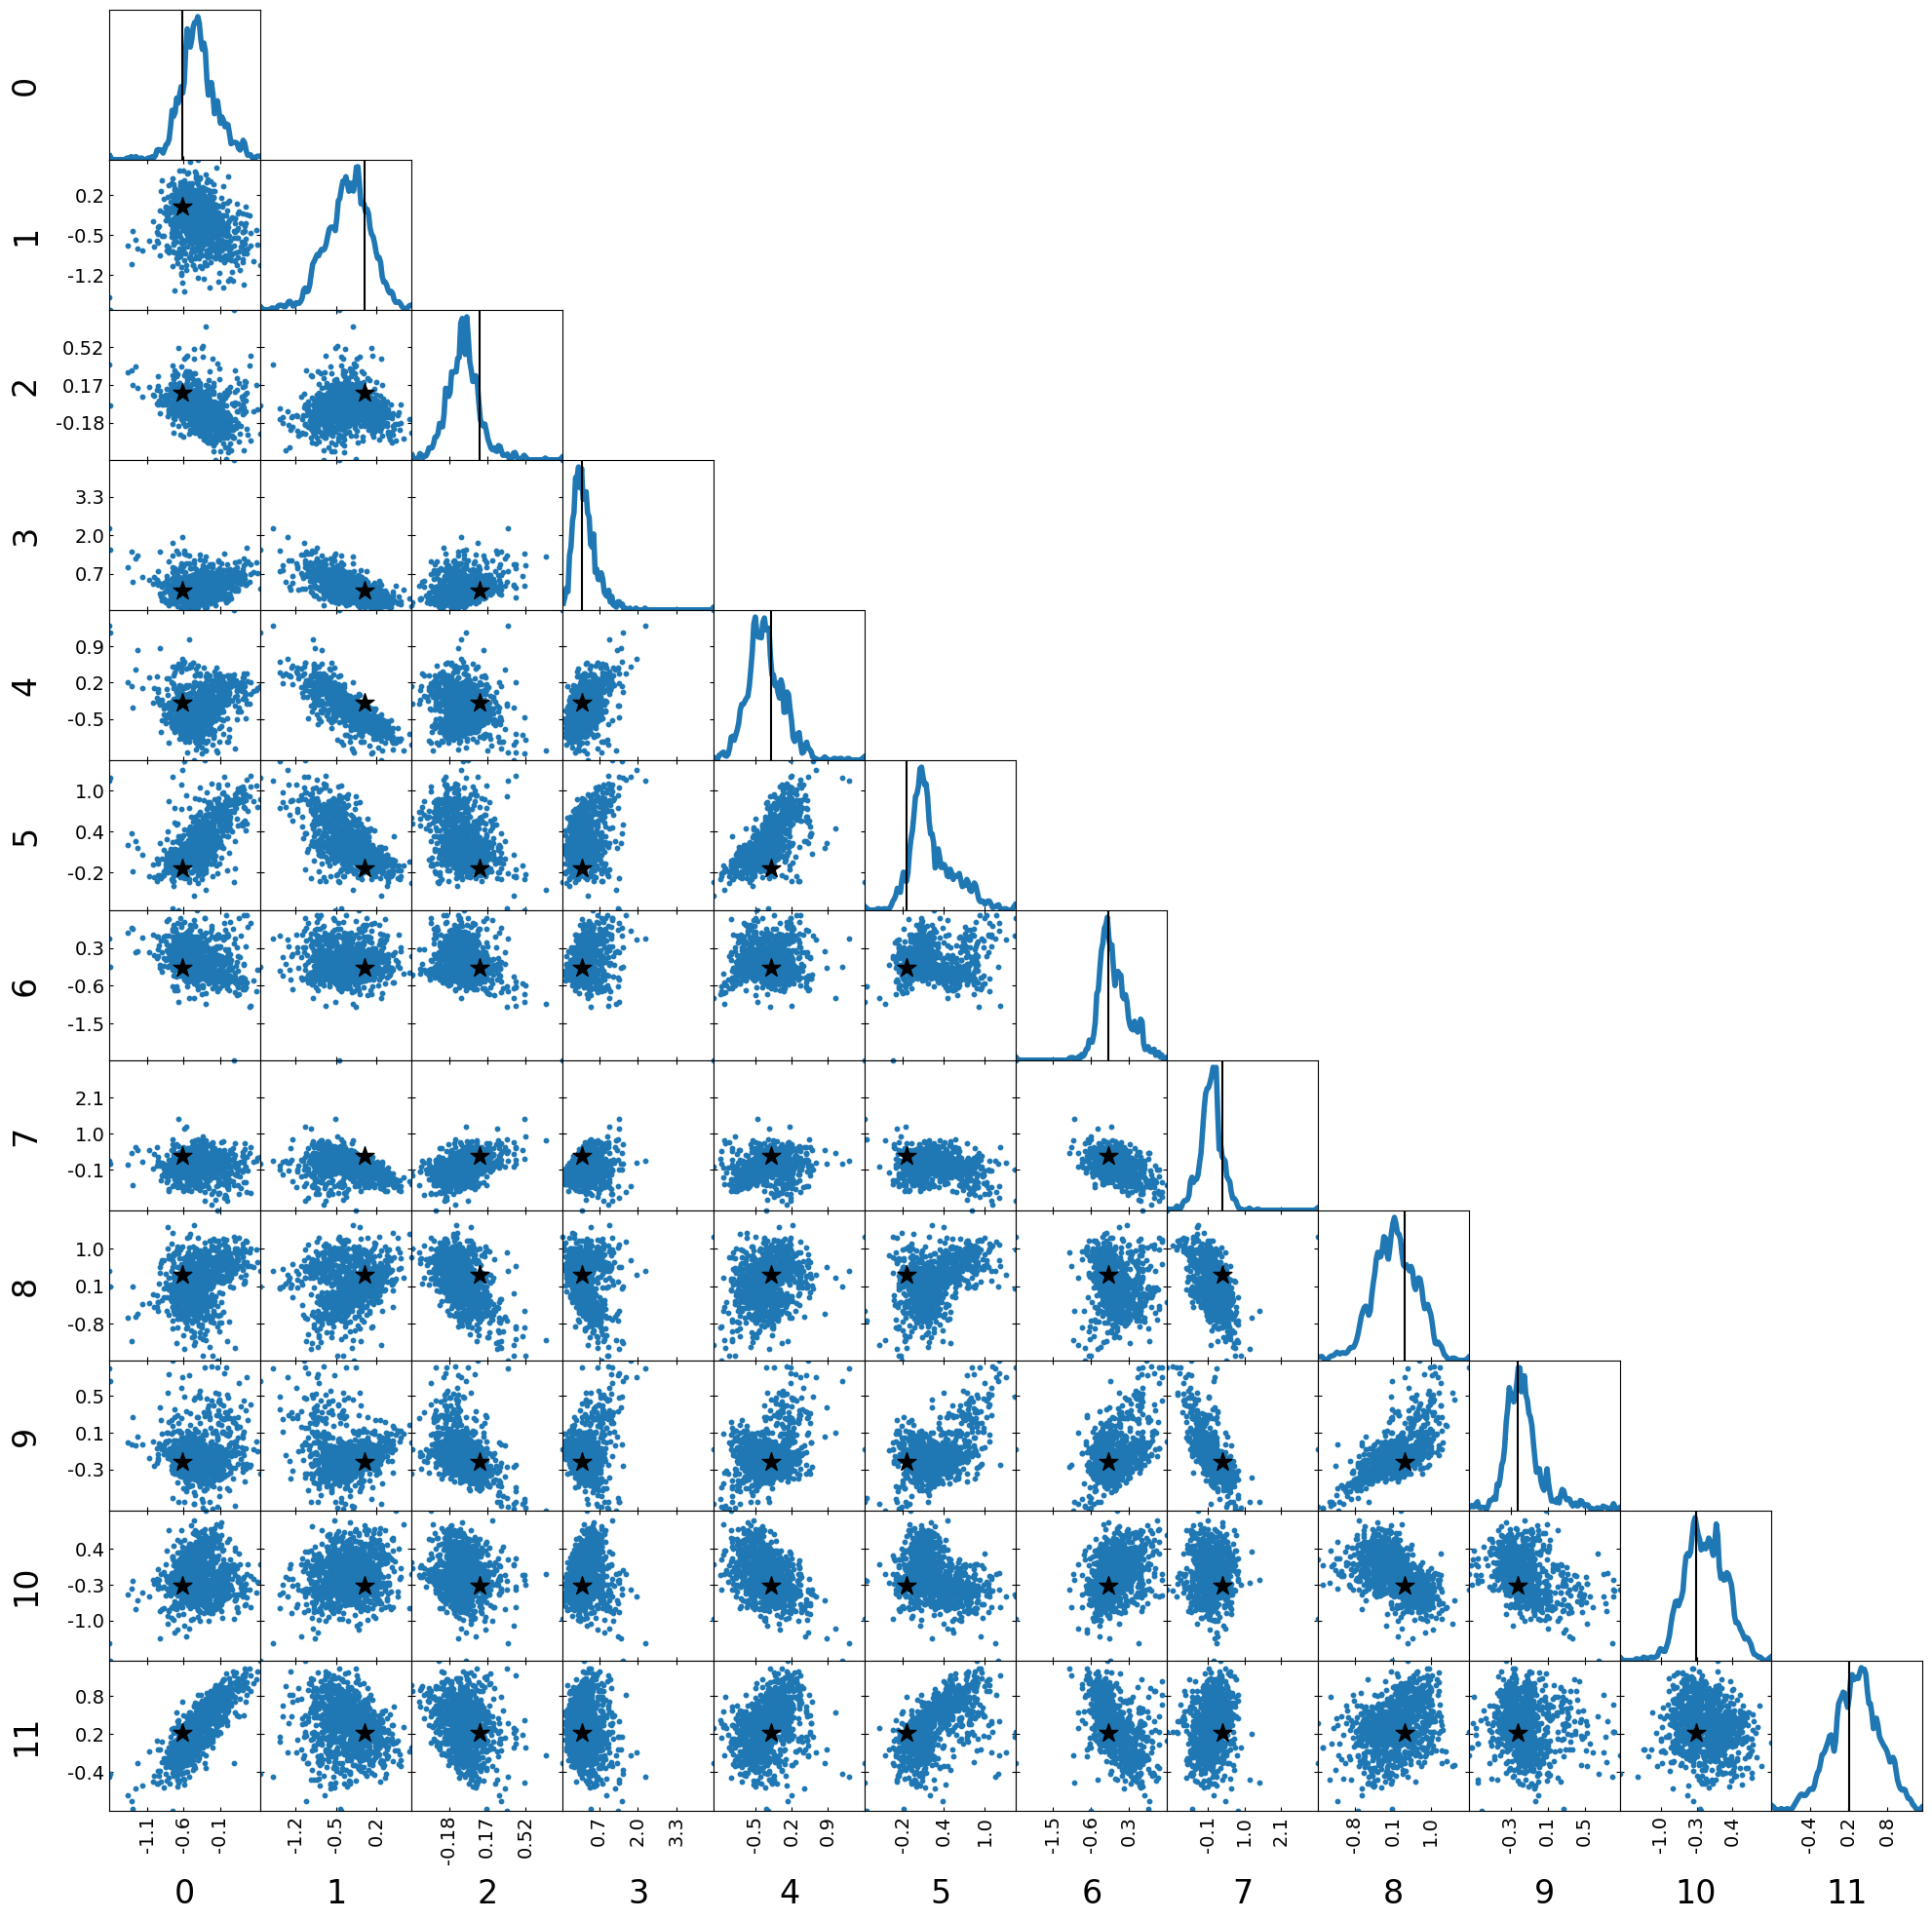

In [16]:
wl_gamma_map, _ = catalog.build_metacal_map_from_cat(msfm_conf)
gc_count_map = catalog.build_maglim_map_from_cat(msfm_conf)

des_cl = preprocessing.get_preprocessed_cl_observation(
    wl_gamma_map=wl_gamma_map,
    gc_count_map=gc_count_map,
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    base_dir=base_dir,
    nest_in=False,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_cross_probe=(with_lensing and with_clustering),
    # additional preprocessing
    apply_log=apply_log,
    standardize=standardize,
    make_plot=False,
)

des_pred = model(des_cl, training=False).numpy()
plot_summary_space_prior_predictive(des_pred)

des_label = "obs/preds/DESy3"
append_obs_to_file(des_label, des_pred)

## Buzzard

In [17]:
n_pix = msfm_conf["analysis"]["n_pix"]

def evaluate_buzzard(obs_label, lensing_file, clustering_file, with_lensing, with_clustering, nest_in=False, plot_diagnostics=False):
    # load the map
    if with_lensing:
        wl_map = buzzard.get_lensing_map(lensing_file, plot_diagnostics=plot_diagnostics)
    else:
        wl_map = np.zeros((n_pix,4,2))

    if with_clustering:
        gc_map = buzzard.get_clustering_map(clustering_file, plot_diagnostics=plot_diagnostics)
    else:
        gc_map = np.zeros((n_pix,4))

    # forward model
    obs_cl = preprocessing.get_preprocessed_cl_observation(
        wl_gamma_map=wl_map,
        gc_count_map=gc_map,
        # configuration
        msfm_conf=msfm_conf,
        dlss_conf=dlss_conf,
        base_dir=base_dir,
        nest_in=False,
        # selection
        with_lensing=with_lensing,
        with_clustering=with_clustering,
        with_cross_z=with_cross_z,
        with_cross_probe=(with_lensing and with_clustering),
        # additional preprocessing
        apply_log=apply_log,
        standardize=standardize,
        make_plot=False,
    )    

    # evaluate
    obs_pred = model(obs_cl, training=False).numpy()
    print(obs_label, ": obs_pred =", obs_pred)

    if plot_diagnostics:
        plot_cls_space_prior_predictive(obs_cl)
        plot_summary_space_prior_predictive(obs_pred)

    # save
    append_obs_to_file(obs_label, obs_pred)

    return obs_pred


In [18]:
# buzzard_indices, lensing_files, clustering_files = buzzard.get_filenames()

# lensing_files = lensing_files[:2]

# buzzards = []
# for i, lensing_file, clustering_file in zip(buzzard_indices, lensing_files, clustering_files):
#     obs_label = f"obs/preds/Buzzard_{i}"
    
#     obs_pred = evaluate_buzzard(
#         obs_label, 
#         lensing_file, 
#         clustering_file, 
#         with_lensing=with_lensing,
#         with_clustering=with_clustering,
#         plot_diagnostics=True
#     )    
    
#     buzzards.append(obs_pred)

# buzzards = np.stack(buzzards, axis=0)
# append_obs_to_file("Buzzard_stack", buzzards)
# append_obs_to_file("Buzzard_mean", np.mean(buzzards, axis=0))
